In [ ]:
# 既にインストールされていれば不要
!pip install quri-parts
!pip install "quri-parts[qulacs]"

In [ ]:
import numpy as np
from quri_parts.circuit import QuantumCircuit
from quri_parts.core.state import quantum_state
from quri_parts.qulacs.simulator import evaluate_state_to_vector

# 量子位相推定(QPE)アルゴリズムに用いる補助量子ビットの数
m = 8
# 合計量子ビット数
n_qubits = m + 1 # 振幅を推定する状態は1量子ビットとする

# 振幅を推定する状態を生成する量子回路
theta = 0.7
circuit_psi = QuantumCircuit(1)
circuit_psi.add_RY_gate(0, theta)

state_psi = quantum_state(1, circuit=circuit_psi)
state_psi_vector = evaluate_state_to_vector(state_psi).vector
print(f"theta: {theta}")
print(f"cos(theta/2)={np.cos(theta/2.):.8f}, sin(theta/2)={np.sin(theta/2.):.8f}")
print(f"状態ベクトル: {state_psi_vector}")
print(f"求めたい振幅sin^2(theta/2): {np.abs(state_psi_vector[1])**2:.8f}")

theta: 0.7
cos(theta/2)=0.93937271, sin(theta/2)=0.34289781
状態ベクトル: [0.93937271+0.j 0.34289781+0.j]
求めたい振幅sin^2(theta/2): 0.11757891


In [ ]:
from quri_parts.circuit.utils.circuit_drawer import draw_circuit

# 制御Qゲート(control-Q) の実装
def create_control_Q(control, target, theta) -> QuantumCircuit:
    circuit = QuantumCircuit(n_qubits)
    # 制御S_chiゲート(control-S_chi)
    circuit.add_CZ_gate(control, target) # |1>の位相を反転

    # control-S_psi = control-RY(theta) * Z * control-RY(theta)^\dagger
    # 制御RY(theta)^\dagger ゲート(control-RY(theta)^\dagger)
    circuit.add_CNOT_gate(control, target)
    circuit.add_RY_gate(target, theta/2.)
    circuit.add_CNOT_gate(control, target)
    circuit.add_RY_gate(target, -theta/2.)
    # 制御Z ゲート(control-Z)
    circuit.add_CZ_gate(control, target) # |1>の位相を反転
    # 制御RY(theta)ゲート(control-RY(theta))
    circuit.add_CNOT_gate(control, target)
    circuit.add_RY_gate(target, -theta/2.)
    circuit.add_CNOT_gate(control, target)
    circuit.add_RY_gate(target, theta/2.)

    return circuit.freeze()

control_Q = create_control_Q(0, m, theta)
draw_circuit(control_Q)

                                                                                
                                                                                
----●-------●---------------●---------------●-------●---------------●-----------
    |       |               |               |       |               |           
    |       |               |               |       |               |           
    |       |               |               |       |               |           
----|-------|---------------|---------------|-------|---------------|-----------
    |       |               |               |       |               |           
    |       |               |               |       |               |           
    |       |               |               |       |               |           
----|-------|---------------|---------------|-------|---------------|-----------
    |       |               |               |       |               |           
    |       |               

In [ ]:
from quri_parts.circuit import inverse_circuit

def create_qft_circuit(n, inverse=False) -> QuantumCircuit:
    # 量子ビットのインデックスは|j_{n-1} j_{n-2}...j_0>の順番
    circuit = QuantumCircuit(n)
    for i in reversed(range(n)): # i は n-1 から 0 まで
        circuit.add_H_gate(i)
        for j in range(i): # j は 0 から i-1 まで
            # 制御位相ゲートを4*4 行列で定義
            # (本来は基礎ゲートRz, control-Rz などに分解する)
            angle = 2 * np.pi / (2 ** (i - j + 1))
            control_phase_mat = np.diag([1,1,1, np.exp(1j * angle)])
            circuit.add_UnitaryMatrix_gate([j, i], control_phase_mat)

    # 量子ビットの順序を反転
    for i in range(n // 2):
        circuit.add_SWAP_gate(i, n - i - 1)

    if inverse:
        return inverse_circuit(circuit).freeze()

    return circuit.freeze()

# Q に関する量子位相推定(QPE)アルゴリズム
def create_qpe_circuit()-> QuantumCircuit:
    circuit = QuantumCircuit(m+1)
    # 補助量子ビットにアダマールゲートを適用
    for i in range(m):
        circuit.add_H_gate(i)
    # i 番目の補助量子ビットを制御量子ビットとしたcontrol-{Q^(2^i)}演算
    for i in range(m):
        control_Q = create_control_Q(i, m, theta)
        # 愚直に2^i 回かける
        for _ in range(2 ** i):
            circuit.extend(control_Q)
    # 逆量子フーリエ変換
    iqft = create_qft_circuit(m, inverse=True)
    circuit.extend(iqft)

    return circuit

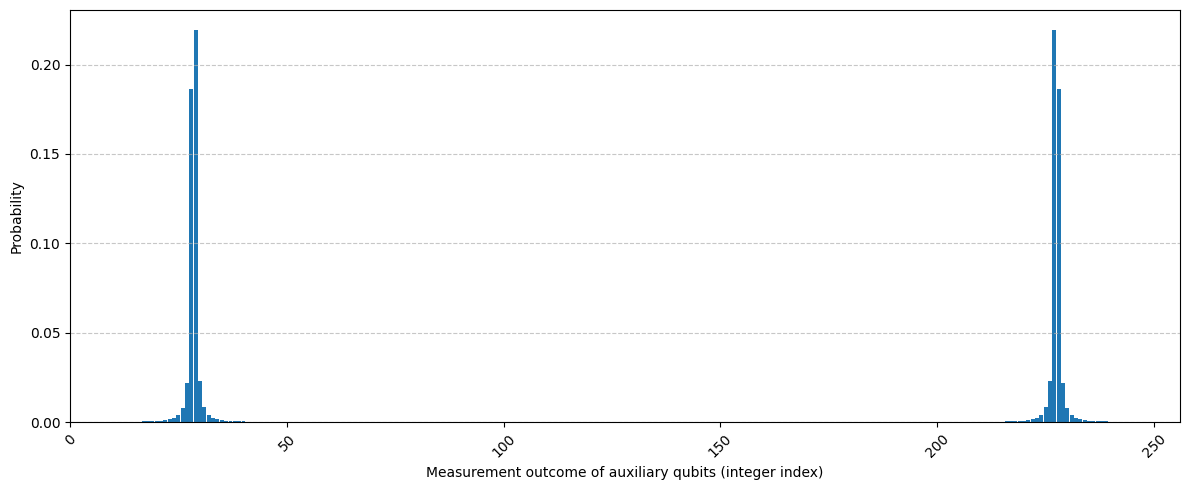

In [ ]:
# 回路の実行
init_circuit = QuantumCircuit(n_qubits)
init_circuit.add_RY_gate(m, theta) # 初期状態の準備
state = quantum_state(n_qubits, circuit=init_circuit + create_qpe_circuit())
result_vector = evaluate_state_to_vector(state).vector

# 補助量子ビットの観測確率を計算
probs_allbits = np.abs(result_vector)**2
reshaped_array = probs_allbits.reshape(2, 2**m)
probs_regbits = reshaped_array.sum(axis=0) # システムレジスタについて周辺化

# プロット
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.bar(np.arange(2**m), probs_regbits, width=0.9)
plt.xlabel("Measurement outcome of auxiliary qubits (integer index)")
plt.ylabel("Probability")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.xlim(0, 2**m)
plt.show()
plt.close()

In [ ]:
# 確率が大きいものについて対応する振幅を計算
print(f"theta = {theta}, sin^2(theta/2) = {np.sin(theta/2)**2:.8f}")
for bit in np.argsort(probs_regbits)[::-1][:5]: # 上位5つのビット
    theta_estimated = bit / (2 ** m) * (2 * np.pi)
    amplitude = np.sin(theta_estimated/2.)**2
    print(f" --- bit={np.binary_repr(bit, width=m)}, 確率={probs_regbits[bit]:.4f} ---")
    print(f"θ={theta_estimated:.4f}, amplitude={amplitude:.8f},"
    f"error={np.abs(amplitude - np.sin(theta/2)**2):.8f}")

theta = 0.7, sin^2(theta/2) = 0.11757891
 --- bit=00011101, 確率=0.2195 ---
θ=0.7118, amplitude=0.12139558,error=0.00381667
 --- bit=11100011, 確率=0.2195 ---
θ=5.5714, amplitude=0.12139558,error=0.00381667
 --- bit=11100100, 確率=0.1862 ---
θ=5.5960, amplitude=0.11349477,error=0.00408413
 --- bit=00011100, 確率=0.1862 ---
θ=0.6872, amplitude=0.11349477,error=0.00408413
 --- bit=11100010, 確率=0.0231 ---
θ=5.5469, amplitude=0.12952444,error=0.01194553
